
=== 比較表（全項目） ===
     graph_name  nodes  edges  avg_degree  density  degree_variance  degree_entropy  closeness_entropy  betweenness_entropy  closeness_min  closeness_max  closeness_mean  closeness_std  closeness_median  betweenness_min  betweenness_max  betweenness_mean  betweenness_std  betweenness_median
    Random (ER)    100    177        3.54 0.035758           3.6684        2.921961           6.589796             5.924657       0.000000       0.349966        0.268883       0.057083          0.275826              0.0         0.131583          0.024482         0.025846            0.017773
Scale-Free (BA)    100    196        3.92 0.039596          21.1736        2.290220           6.630347             4.546019       0.277311       0.546961        0.356909       0.049605          0.360005              0.0         0.408761          0.018905         0.053311            0.002763

[Random (ER)]
ノード数                     : 100
エッジ数                     : 177
平均次数                     : 3.

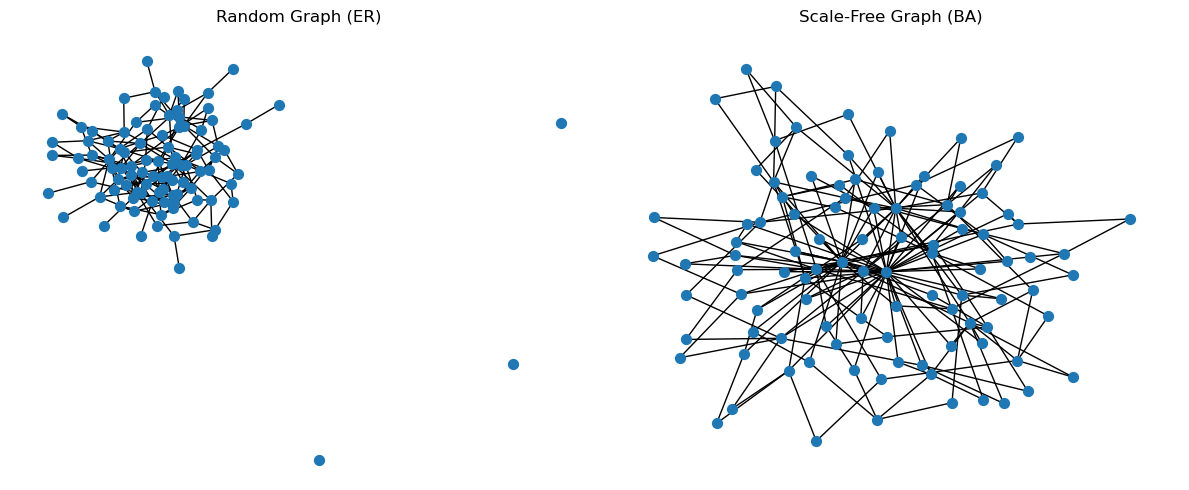

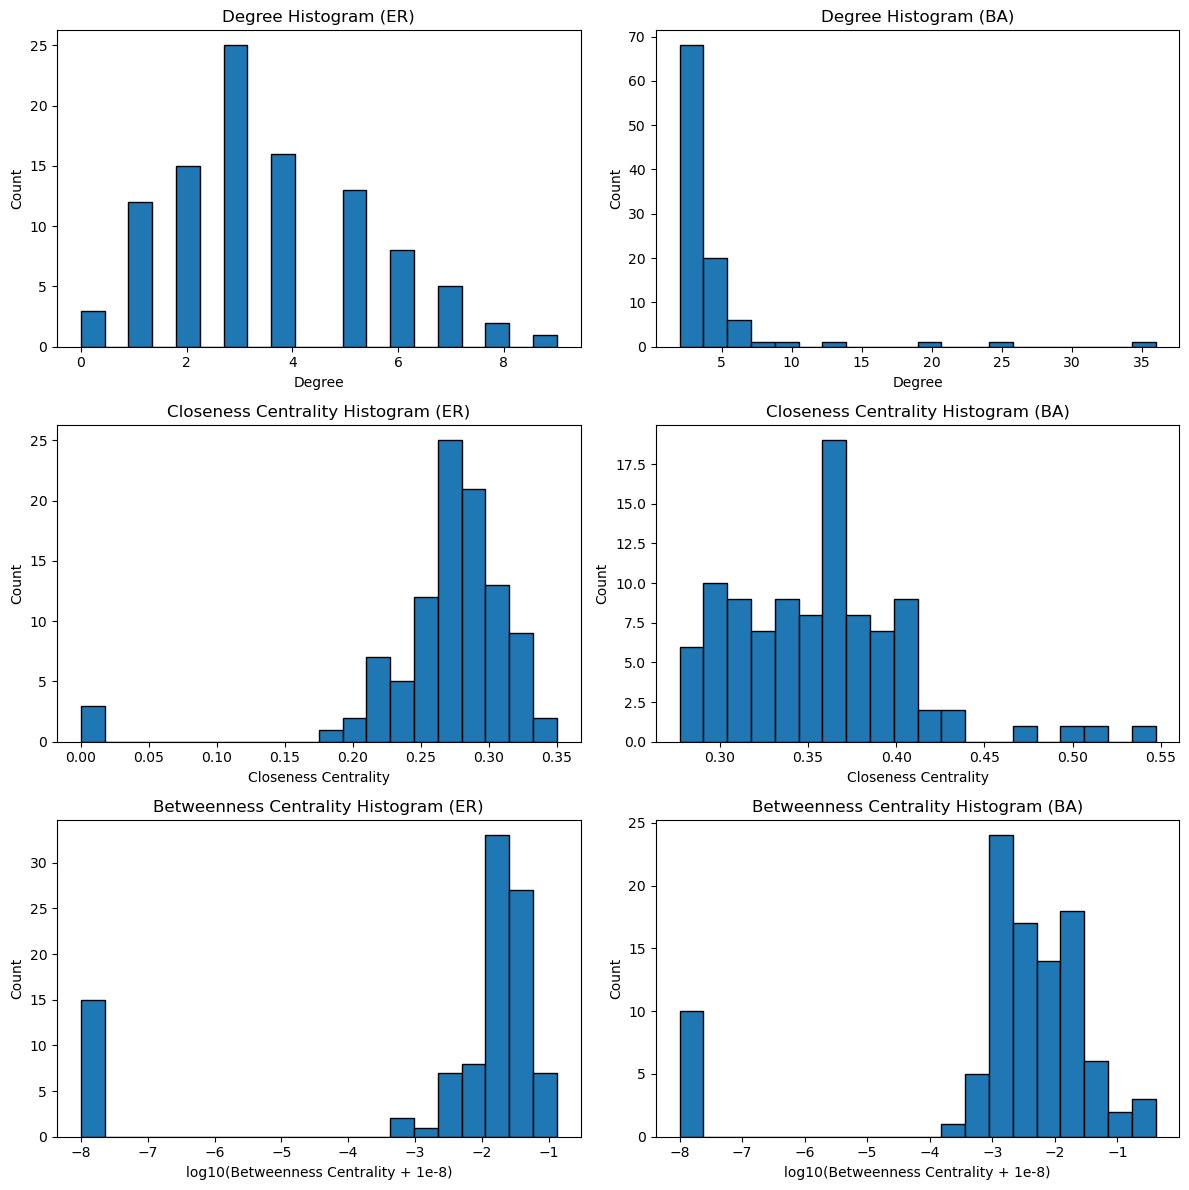


=== エントロピー比較表（最終） ===
     graph_name  degree_entropy  closeness_entropy  betweenness_entropy
    Random (ER)        2.921961           6.589796             5.924657
Scale-Free (BA)        2.290220           6.630347             4.546019


In [9]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# =========================================
# 0. パラメータ
# =========================================
SEED = 42

# ノード数
N = 100

# BAグラフ用（スケールフリー）
M_BA = 2

# ERグラフ用
# None の場合、BA の平均次数 2*M_BA に合わせる
P_ER = None

# 描画設定
DRAW_GRAPH = True
DRAW_HIST = True

# ヒストグラム設定
BINS = 20

# 媒介中心性ヒストグラムを対数表示にするか
USE_LOG_FOR_BETWEENNESS = True

# 数値安定化
EPS = 1e-12


# =========================================
# 1. 共通関数
# =========================================
def shannon_entropy(prob, eps=1e-12):
    """
    確率分布 prob に対するシャノンエントロピー
    """
    p = np.array(prob, dtype=float)
    p = p[p > 0]
    if len(p) == 0:
        return 0.0
    p = np.clip(p, eps, 1.0)
    return -np.sum(p * np.log2(p))


def entropy_from_values(values, eps=1e-12):
    """
    非負値列を確率化してエントロピー計算
    """
    arr = np.array(values, dtype=float)
    total = arr.sum()
    if total <= 0:
        return 0.0
    p = arr / total
    return shannon_entropy(p, eps)


def describe_array(arr):
    """
    配列の要約統計
    """
    arr = np.array(arr, dtype=float)
    return {
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "median": float(np.median(arr)),
    }


# =========================================
# 2. 指標関数
# =========================================
def degree_values(G):
    return np.array([d for _, d in G.degree()], dtype=float)


def degree_variance(G):
    deg = degree_values(G)
    return float(np.var(deg))


def degree_entropy(G, eps=1e-12):
    """
    次数分布のエントロピー
    """
    deg = [d for _, d in G.degree()]
    cnt = Counter(deg)
    freq = np.array(list(cnt.values()), dtype=float)
    prob = freq / freq.sum()
    return float(shannon_entropy(prob, eps))


def closeness_dict(G):
    return nx.closeness_centrality(G)


def closeness_values(G):
    return np.array(list(closeness_dict(G).values()), dtype=float)


def closeness_entropy(G, eps=1e-12):
    vals = closeness_values(G)
    return float(entropy_from_values(vals, eps))


def betweenness_dict(G):
    return nx.betweenness_centrality(G, normalized=True)


def betweenness_values(G):
    return np.array(list(betweenness_dict(G).values()), dtype=float)


def betweenness_entropy(G, eps=1e-12):
    vals = betweenness_values(G)
    return float(entropy_from_values(vals, eps))


def summarize_graph(G, graph_name, eps=1e-12):
    deg = degree_values(G)
    clo = closeness_values(G)
    bet = betweenness_values(G)

    deg_desc = describe_array(deg)
    clo_desc = describe_array(clo)
    bet_desc = describe_array(bet)

    result = {
        "graph_name": graph_name,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "avg_degree": float(np.mean(deg)),
        "density": float(nx.density(G)),

        "degree_variance": degree_variance(G),
        "degree_entropy": degree_entropy(G, eps),

        "closeness_entropy": closeness_entropy(G, eps),
        "betweenness_entropy": betweenness_entropy(G, eps),

        "closeness_min": clo_desc["min"],
        "closeness_max": clo_desc["max"],
        "closeness_mean": clo_desc["mean"],
        "closeness_std": clo_desc["std"],
        "closeness_median": clo_desc["median"],

        "betweenness_min": bet_desc["min"],
        "betweenness_max": bet_desc["max"],
        "betweenness_mean": bet_desc["mean"],
        "betweenness_std": bet_desc["std"],
        "betweenness_median": bet_desc["median"],
    }

    return result, deg, clo, bet


# =========================================
# 3. グラフ生成
# =========================================
G_ba = nx.barabasi_albert_graph(N, M_BA, seed=SEED)

if P_ER is None:
    p_er = (2 * M_BA) / (N - 1)
else:
    p_er = P_ER

G_er = nx.erdos_renyi_graph(N, p_er, seed=SEED)


# =========================================
# 4. 計算
# =========================================
res_er, deg_er, clo_er, bet_er = summarize_graph(G_er, "Random (ER)", eps=EPS)
res_ba, deg_ba, clo_ba, bet_ba = summarize_graph(G_ba, "Scale-Free (BA)", eps=EPS)

df = pd.DataFrame([res_er, res_ba])


# =========================================
# 5. 比較表（省略なし）
# =========================================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

print("\n=== 比較表（全項目） ===")
print(df.to_string(index=False))


# =========================================
# 6. 個別詳細表示（省略なし）
# =========================================
for _, row in df.iterrows():
    print("\n" + "=" * 60)
    print(f"[{row['graph_name']}]")
    print("=" * 60)

    print(f"ノード数                     : {int(row['nodes'])}")
    print(f"エッジ数                     : {int(row['edges'])}")
    print(f"平均次数                     : {row['avg_degree']:.6f}")
    print(f"密度                         : {row['density']:.6f}")

    print(f"次数分散                     : {row['degree_variance']:.6f}")
    print(f"次数エントロピー             : {row['degree_entropy']:.6f}")

    print(f"近接中心性エントロピー       : {row['closeness_entropy']:.6f}")
    print(f"媒介中心性エントロピー       : {row['betweenness_entropy']:.6f}")

    print("\n[近接中心性の要約統計]")
    print(f"  最小値                     : {row['closeness_min']:.6f}")
    print(f"  最大値                     : {row['closeness_max']:.6f}")
    print(f"  平均                       : {row['closeness_mean']:.6f}")
    print(f"  標準偏差                   : {row['closeness_std']:.6f}")
    print(f"  中央値                     : {row['closeness_median']:.6f}")

    print("\n[媒介中心性の要約統計]")
    print(f"  最小値                     : {row['betweenness_min']:.6f}")
    print(f"  最大値                     : {row['betweenness_max']:.6f}")
    print(f"  平均                       : {row['betweenness_mean']:.6f}")
    print(f"  標準偏差                   : {row['betweenness_std']:.6f}")
    print(f"  中央値                     : {row['betweenness_median']:.6f}")


# =========================================
# 7. グラフ可視化
# =========================================
if DRAW_GRAPH:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    pos_er = nx.spring_layout(G_er, seed=SEED)
    nx.draw(
        G_er,
        pos_er,
        ax=axes[0],
        node_size=50,
        with_labels=False
    )
    axes[0].set_title("Random Graph (ER)")

    pos_ba = nx.spring_layout(G_ba, seed=SEED)
    nx.draw(
        G_ba,
        pos_ba,
        ax=axes[1],
        node_size=50,
        with_labels=False
    )
    axes[1].set_title("Scale-Free Graph (BA)")

    plt.tight_layout()
    plt.show()


# =========================================
# 8. ヒストグラム可視化
# =========================================
if DRAW_HIST:
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))

    # -------------------------
    # 8-1. 次数ヒストグラム
    # -------------------------
    axes[0, 0].hist(deg_er, bins=BINS, edgecolor="black")
    axes[0, 0].set_title("Degree Histogram (ER)")
    axes[0, 0].set_xlabel("Degree")
    axes[0, 0].set_ylabel("Count")

    axes[0, 1].hist(deg_ba, bins=BINS, edgecolor="black")
    axes[0, 1].set_title("Degree Histogram (BA)")
    axes[0, 1].set_xlabel("Degree")
    axes[0, 1].set_ylabel("Count")

    # -------------------------
    # 8-2. 近接中心性ヒストグラム
    # -------------------------
    axes[1, 0].hist(clo_er, bins=BINS, edgecolor="black")
    axes[1, 0].set_title("Closeness Centrality Histogram (ER)")
    axes[1, 0].set_xlabel("Closeness Centrality")
    axes[1, 0].set_ylabel("Count")

    axes[1, 1].hist(clo_ba, bins=BINS, edgecolor="black")
    axes[1, 1].set_title("Closeness Centrality Histogram (BA)")
    axes[1, 1].set_xlabel("Closeness Centrality")
    axes[1, 1].set_ylabel("Count")

    # -------------------------
    # 8-3. 媒介中心性ヒストグラム
    # -------------------------
    if USE_LOG_FOR_BETWEENNESS:
        bet_er_plot = np.log10(bet_er + 1e-8)
        bet_ba_plot = np.log10(bet_ba + 1e-8)
        bet_xlabel = "log10(Betweenness Centrality + 1e-8)"
    else:
        bet_er_plot = bet_er
        bet_ba_plot = bet_ba
        bet_xlabel = "Betweenness Centrality"

    axes[2, 0].hist(bet_er_plot, bins=BINS, edgecolor="black")
    axes[2, 0].set_title("Betweenness Centrality Histogram (ER)")
    axes[2, 0].set_xlabel(bet_xlabel)
    axes[2, 0].set_ylabel("Count")

    axes[2, 1].hist(bet_ba_plot, bins=BINS, edgecolor="black")
    axes[2, 1].set_title("Betweenness Centrality Histogram (BA)")
    axes[2, 1].set_xlabel(bet_xlabel)
    axes[2, 1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    # =========================================
# 9. エントロピー比較表（最終まとめ）
# =========================================
entropy_df = df[[
    "graph_name",
    "degree_entropy",
    "closeness_entropy",
    "betweenness_entropy"
]].copy()

# 見やすく丸める
entropy_df["degree_entropy"] = entropy_df["degree_entropy"].round(6)
entropy_df["closeness_entropy"] = entropy_df["closeness_entropy"].round(6)
entropy_df["betweenness_entropy"] = entropy_df["betweenness_entropy"].round(6)

print("\n=== エントロピー比較表（最終） ===")
print(entropy_df.to_string(index=False))